In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.ensemble import IsolationForest

In [15]:
df = pd.read_csv("adult_with_headers (1).csv")
df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education_num   32561 non-null  int64 
 5   marital_status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital_gain    32561 non-null  int64 
 11  capital_loss    32561 non-null  int64 
 12  hours_per_week  32561 non-null  int64 
 13  native_country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [17]:
df.describe()

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [18]:
df.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
income            0
dtype: int64

In [19]:
# Select Numerical Columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

In [20]:
# Standard Scaling
scaler = StandardScaler()
df_standard = df.copy()
df_standard[num_cols] = scaler.fit_transform(df[num_cols])

In [21]:
# Min-Max Scaling
minmax = MinMaxScaler()
df_minmax = df.copy()
df_minmax[num_cols] = minmax.fit_transform(df[num_cols])

In [22]:
# Encoding Techniques
# Find categorical columns
cat_cols = df.select_dtypes(include='object').columns

In [23]:
# One-Hot Encoding
low_card_cols = [col for col in cat_cols if df[col].nunique() < 5]

df = pd.get_dummies(df, columns=low_card_cols)

cat_cols = df.select_dtypes(include='object').columns

In [24]:
# Label Encoding
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

In [25]:
print(df.columns)

Index(['age', 'workclass', 'fnlwgt', 'education', 'education_num',
       'marital_status', 'occupation', 'relationship', 'race', 'capital_gain',
       'capital_loss', 'hours_per_week', 'native_country', 'sex_ Female',
       'sex_ Male', 'income_ <=50K', 'income_ >50K'],
      dtype='object')


## Feature Engineering
- Create New Features
- Feature 1: Age Group

In [26]:
df['age_group'] = pd.cut(df['age'], bins=[0,25,50,100], labels=['Young','Adult','Old'])

In [28]:
# Hours Category
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

df['work_intensity'] = pd.cut(df['hours_per_week'],
                             bins=[0,25,40,100],
                             labels=['low','medium','high'])

<Axes: xlabel='capital_gain', ylabel='Count'>

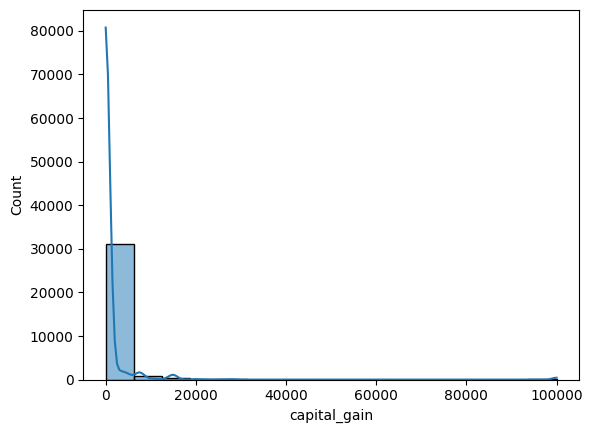

In [30]:
# Log Transformation (Skewed Feature)
sns.histplot(df['capital_gain'], kde=True)

In [31]:
df['capital_gain'] = np.log1p(df['capital_gain'])

In [32]:
# Outlier Detection (Isolation Forest)
iso = IsolationForest(contamination=0.05)

df['outlier'] = iso.fit_predict(df[num_cols])

# Remove outliers
df = df[df['outlier'] == 1]
df.drop('outlier', axis=1, inplace=True)

C:\Users\SHAIKH\AppData\Local\Temp\ipykernel_9096\96013340.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop('outlier', axis=1, inplace=True)


In [ ]:
# Feature Selection
corr = df.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap='coolwarm')
plt.show()

In [ ]:
df.head()
df.shape